# 04 - Visualizations
Univariate and bivariate charts with short insights for each.

## Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

conn = sqlite3.connect('../data/movies.db')
movies = pd.read_sql('SELECT * FROM movies', conn, parse_dates=['release_date'])
genres = pd.read_sql('SELECT * FROM genres', conn)
movie_genres = pd.read_sql('SELECT * FROM movie_genres', conn)
conn.close()

movies['budget_known'] = movies['budget_known'].astype(bool)
movies['revenue_known'] = movies['revenue_known'].astype(bool)
movies['release_year'] = movies['release_date'].dt.year

movie_genres_named = movie_genres.merge(genres, on='genre_id')
movies_genre_expanded = movies.merge(movie_genres_named, on='movie_id')

print("Data ready:", movies.shape)

Data ready: (2503, 15)


---
## Univariate Analysis

### 1. Distribution of Movie Budgets

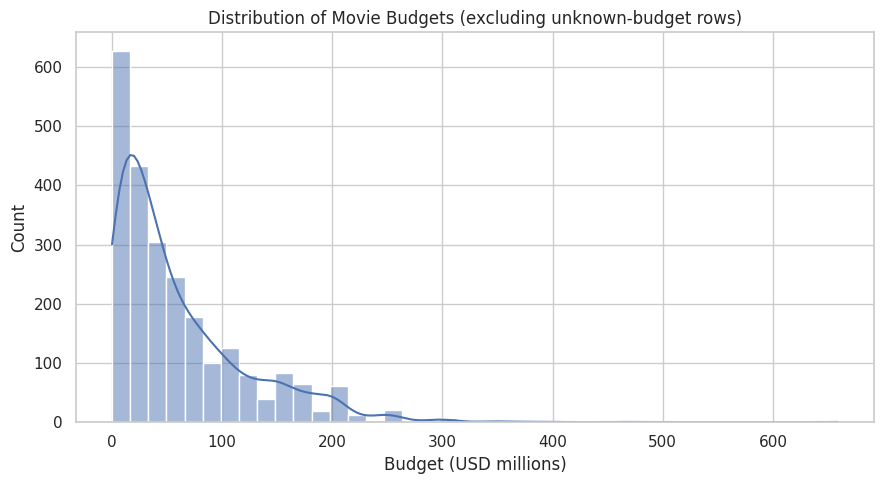

In [2]:
budget_known_df = movies[movies['budget_known']]

fig, ax = plt.subplots()
sns.histplot(budget_known_df['budget'] / 1e6, bins=40, kde=True, ax=ax, color='#4C72B0')
ax.set_xlabel('Budget (USD millions)')
ax.set_title('Distribution of Movie Budgets (excluding unknown-budget rows)')
plt.tight_layout()
plt.show()

Right-skewed - most movies cost well under $50M, with a handful of $300M+ tentpoles pulling the tail out. Average budget alone would be misleading without a median.

### 2. Distribution of Runtimes

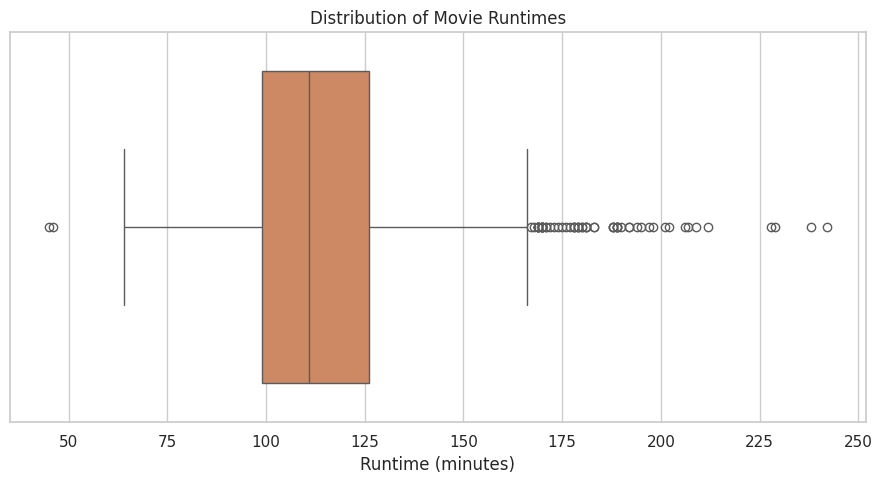

count    2503.000000
mean      114.413903
std        21.418867
min        45.000000
25%        99.000000
50%       111.000000
75%       126.000000
max       242.000000
Name: runtime, dtype: float64


In [3]:
fig, ax = plt.subplots()
sns.boxplot(x=movies['runtime'], ax=ax, color='#DD8452')
ax.set_xlabel('Runtime (minutes)')
ax.set_title('Distribution of Movie Runtimes')
plt.tight_layout()
plt.show()

print(movies['runtime'].describe())

Most runtimes sit between ~95-130 min, matching typical theatrical length. Short outliers are usually animated/specials, long ones are epics - same ones flagged in the Pandas notebook.

### 3. Distribution of Vote Average (Ratings)

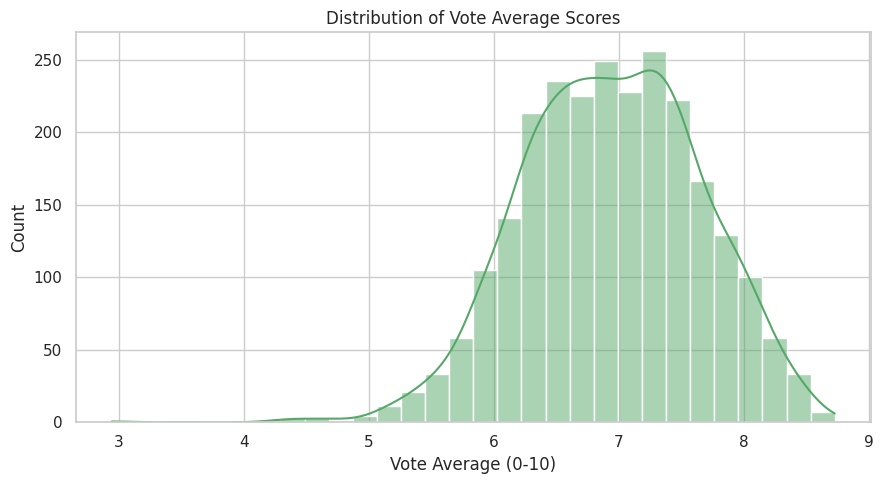

In [4]:
fig, ax = plt.subplots()
sns.histplot(movies['vote_average'], bins=30, kde=True, ax=ax, color='#55A868')
ax.set_xlabel('Vote Average (0-10)')
ax.set_title('Distribution of Vote Average Scores')
plt.tight_layout()
plt.show()

Ratings are roughly bell-shaped, centered around 6.5-7. Very few movies rated below 4, likely because low-vote-count flops don't make it into a curated dataset like this.

### 4. Count of Movies per Genre

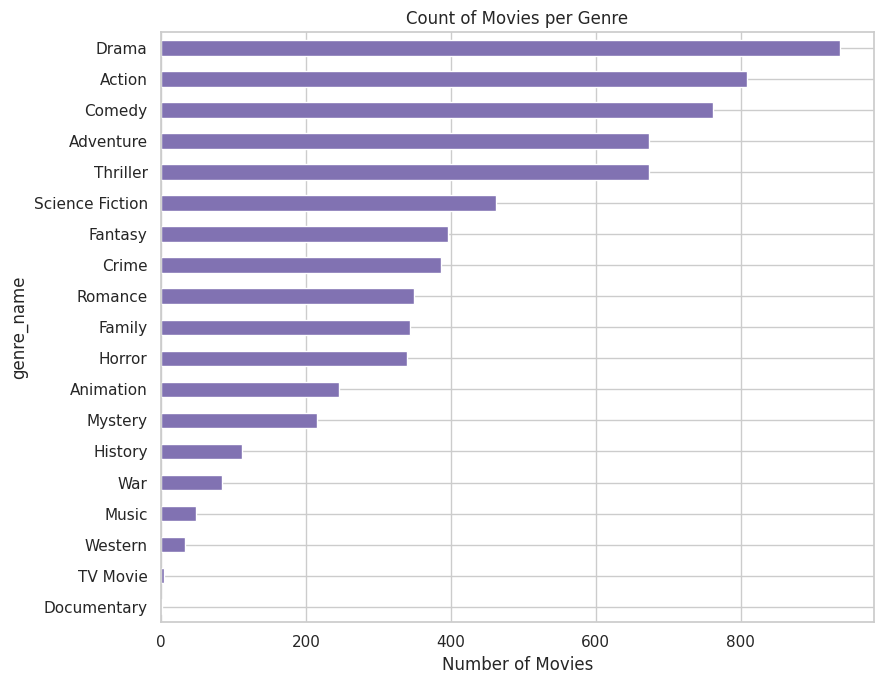

In [5]:
genre_counts = (movies_genre_expanded['genre_name']
                .value_counts()
                .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 7))
genre_counts.plot(kind='barh', ax=ax, color='#8172B2')
ax.set_xlabel('Number of Movies')
ax.set_title('Count of Movies per Genre')
plt.tight_layout()
plt.show()

Drama and Comedy dominate by count (movies can have multiple genres), while Western/TV Movie are rare. That imbalance is why Q9's rating-by-genre needs a minimum movie count.

---
## Bivariate Analysis

### 5. Budget vs. Revenue

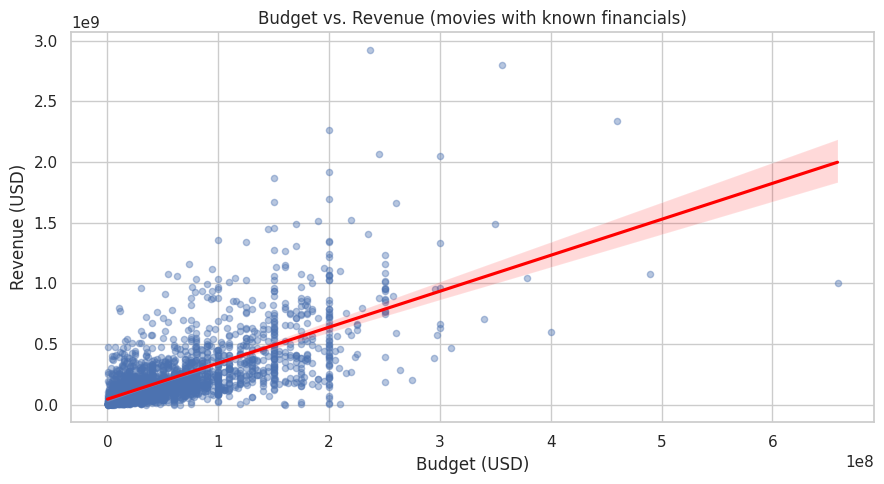

Correlation: 0.68


In [6]:
valid_fin = movies[movies['budget_known'] & movies['revenue_known']]

fig, ax = plt.subplots()
sns.regplot(data=valid_fin, x='budget', y='revenue', ax=ax,
            scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red'})
ax.set_xlabel('Budget (USD)')
ax.set_ylabel('Revenue (USD)')
ax.set_title('Budget vs. Revenue (movies with known financials)')
plt.tight_layout()
plt.show()

corr = valid_fin['budget'].corr(valid_fin['revenue'])
print(f"Correlation: {corr:.2f}")

Clear positive trend but far from a straight line - plenty of high-budget flops below the line and cheap breakout hits above it. Budget alone doesn't predict revenue well.

### 6. Popularity vs. Vote Count

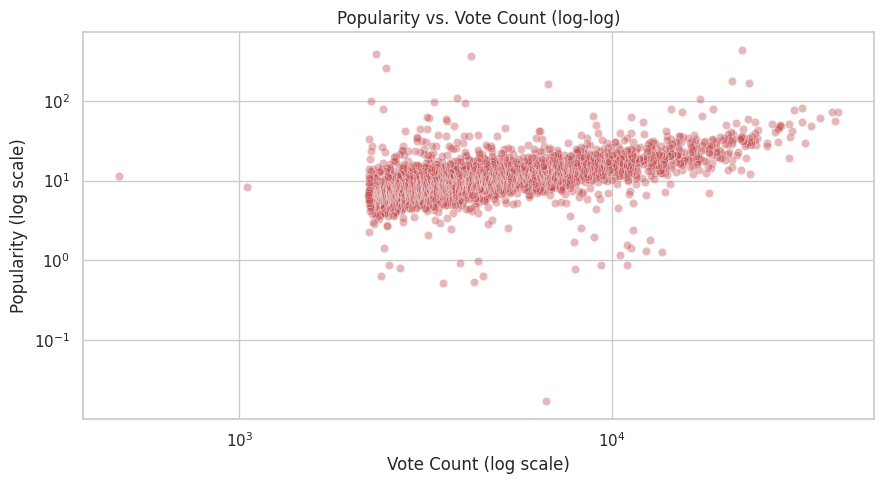

In [7]:
pv = movies[(movies['popularity'] > 0) & (movies['vote_count'] > 0)]

fig, ax = plt.subplots()
sns.scatterplot(data=pv, x='vote_count', y='popularity', alpha=0.4, ax=ax, color='#C44E52')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Vote Count (log scale)')
ax.set_ylabel('Popularity (log scale)')
ax.set_title('Popularity vs. Vote Count (log-log)')
plt.tight_layout()
plt.show()

General upward trend on a log-log scale but wide scatter - same pattern behind the Q10 mismatch analysis. Points above the cloud are trending now, points below are older titles with a big vote history but less current buzz.

### 7. Average Rating by Genre

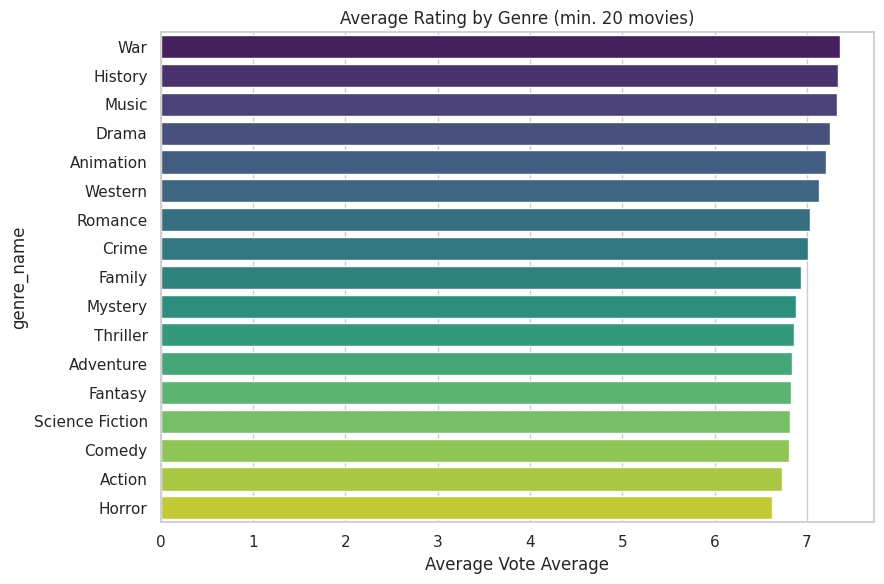

In [8]:
genre_min_count = 20
genre_rating = (movies_genre_expanded.groupby('genre_name')
                .agg(avg_rating=('vote_average', 'mean'), movie_count=('movie_id', 'nunique'))
                .query('movie_count >= @genre_min_count')
                .sort_values('avg_rating', ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=genre_rating['avg_rating'], y=genre_rating.index, ax=ax, palette='viridis',
            hue=genre_rating.index, legend=False)
ax.set_xlabel('Average Vote Average')
ax.set_title(f'Average Rating by Genre (min. {genre_min_count} movies)')
plt.tight_layout()
plt.show()

War, History and Drama rate highest - prestige genres. Horror sits lower, likely because of a bigger, more polarized voting base rather than worse quality.

### 8. Number of Movies Released per Year

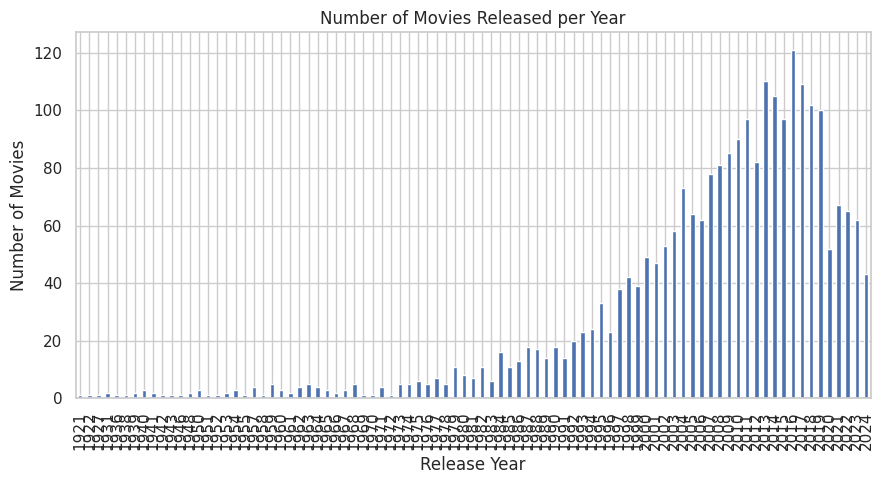

In [9]:
by_year = movies.dropna(subset=['release_year']).groupby('release_year').size()
by_year = by_year[by_year.index <= 2024]

fig, ax = plt.subplots()
by_year.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Movies')
ax.set_title('Number of Movies Released per Year')
plt.tight_layout()
plt.show()

Output grows through the mid-2010s, peaks around 2016, then drops off after 2020 - that's the COVID production/release slowdown, not a real decline in the industry.

## Summary
- Budget, revenue, and vote count are all right-skewed - use median alongside any average.
- Budget only loosely predicts revenue.
- The 2020+ dip in release volume is a pandemic artifact, not an industry decline.